# AI Engineer Roadmap
## Mathematics
### https://zazencodes.com/courses/ai-engineer-roadmap#mathematics

In [1]:
import numpy as np
u = np.random.uniform(0, 1)  # generates one random number between 0 and 1
print(u)


0.23850876315526814


In [4]:
mu = 0
sigma = 1
samples = np.random.normal(mu, sigma, size=10)  # Standard normal distribution
print(samples)

[-1.15792309 -0.89141746 -0.52147722  0.17207065 -0.8497819   2.0878442
  0.16309437  0.3698146  -1.04814567 -1.81385651]


In [5]:
def box_muller():
    """
    Box-Muller Transform: Take two uniform random numbers and convert them to two normal random numbers
    """
    u1 = np.random.uniform(0, 1)
    u2 = np.random.uniform(0, 1)
    z1 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
    z2 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)
    return z1, z2


print(box_muller())


(-1.5272703953672073, -0.9528606882956586)


In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

# Data
emails = ["Buy now!", "Limited offer", "Hello friend", "Meeting schedule"]
labels = [1, 1, 0, 0]  # 1 = Spam, 0 = Not Spam

# Transform text to feature vectors
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# Train Naive Bayes model
model = MultinomialNB()
model.fit(X, labels)

# Predict on new data
test_email = vectorizer.transform(["Special offer"])
prediction = model.predict(test_email)
prediction_proba = model.predict_proba(test_email)


if prediction[0] == 0:
    print(f"Not Spam ({prediction_proba[0][0]:.2f}% probability)")
elif prediction[0] == 1:
    print(f"Spam ({prediction_proba[0][1]:.2f}% probability)")

Spam (0.67% probability)


## Figures

The code below was used to generate plots to include as figures in the lessons.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def plot_clt(n_trials, n_flips_per_trial=1000, x_lims=None):
    """
    Plot the Central Limit Theorem for a weighted coin flip.

    Args:
        n_trials (int): Number of trials to simulate.
        n_flips_per_trial (int): Number of flips per trial.
        x_lims (tuple): Tuple of (x_min, x_max) for the x-axis.
    """
    np.random.seed(137)

    heads_counts = np.array([np.random.binomial(n=1, p=0.9, size=n_flips_per_trial).sum() for _ in range(n_trials)])

    # Dracula theme colors
    bg_color   = '#282a36'
    fg_color   = '#f8f8f2'
    hist_color = '#bd93f9'   # purple
    curve_color = '#50fa7b'  # green

    # Histogram parameters
    if x_lims is not None:
        bins = np.arange(x_lims[0], x_lims[1]+1, 1)
    else:
        bins = np.arange(int(n_flips_per_trial - n_flips_per_trial/5), n_flips_per_trial+1, 1)

    # Theoretical normal distribution
    mu = n_flips_per_trial * 0.9
    sigma = np.sqrt(n_flips_per_trial * 0.9 * 0.1)
    x = np.linspace(bins.min(), bins.max(), 400)
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    # Histogram
    bin_width = bins[1] - bins[0]
    ax.hist(heads_counts, bins=bins, color=hist_color, edgecolor=hist_color, alpha=0.8)

    # Overlay normal curve scaled to histogram
    ax.plot(x, pdf * len(heads_counts) * bin_width, color=curve_color, linewidth=2)

    # Labels and title
    ax.set_xlabel(f'Number of heads in {n_flips_per_trial} flips', color=fg_color, fontsize=12)
    ax.set_ylabel(f'Frequency (out of {n_trials} trials)', color=fg_color, fontsize=12)
    ax.set_title('Central Limit Theorem Demonstration', color=fg_color, fontsize=14)

    ax.legend(['Normal distribution fit', 'Simulated distribution'], loc='upper right')

    # Tick and spine colors
    ax.tick_params(colors=fg_color)
    for spine in ax.spines.values():
        spine.set_color(fg_color)

    plt.tight_layout()
    plt.show()


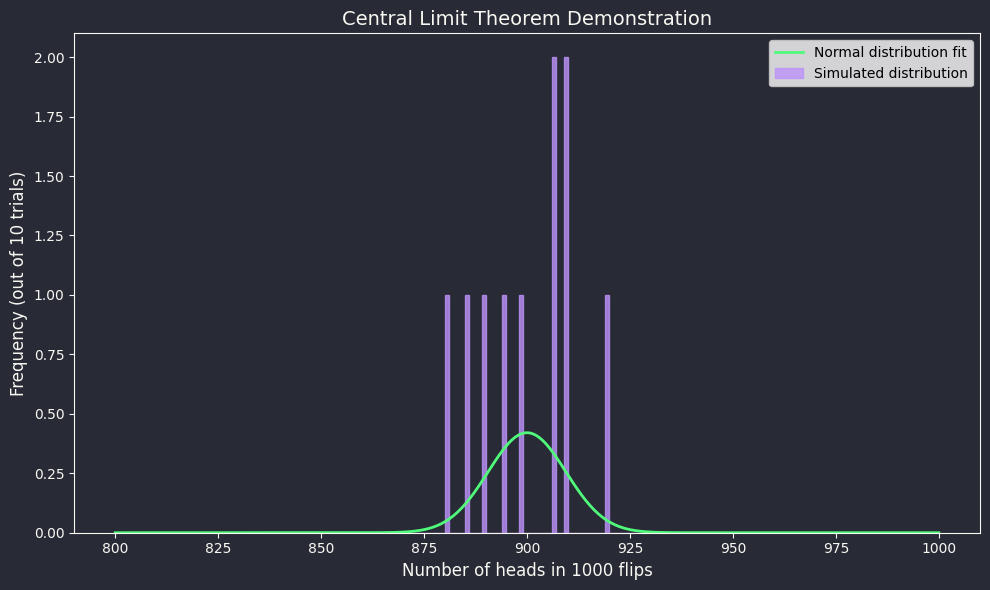

In [2]:
plot_clt(10)

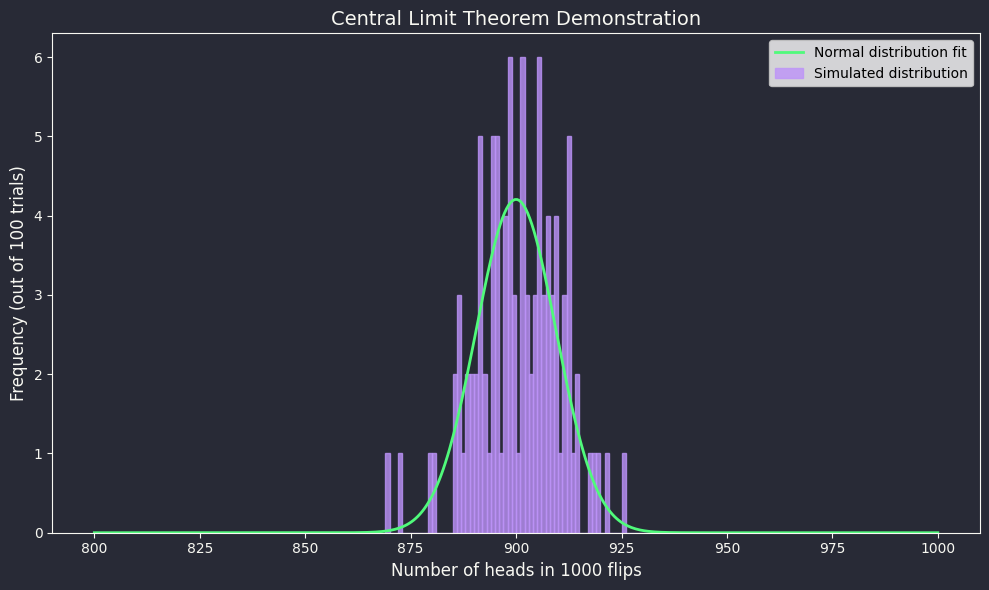

In [3]:
plot_clt(100)

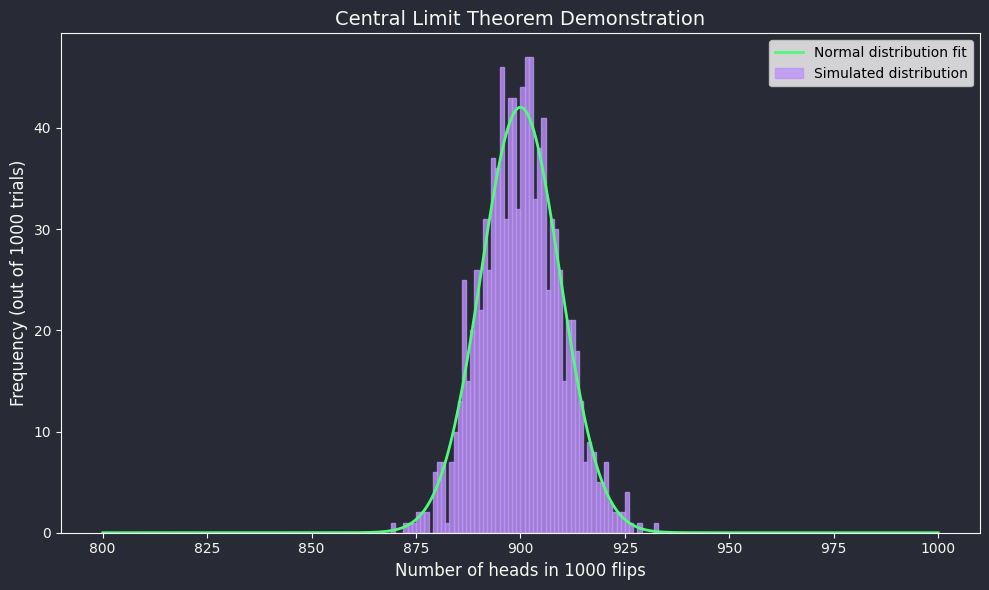

In [4]:
plot_clt(1000)

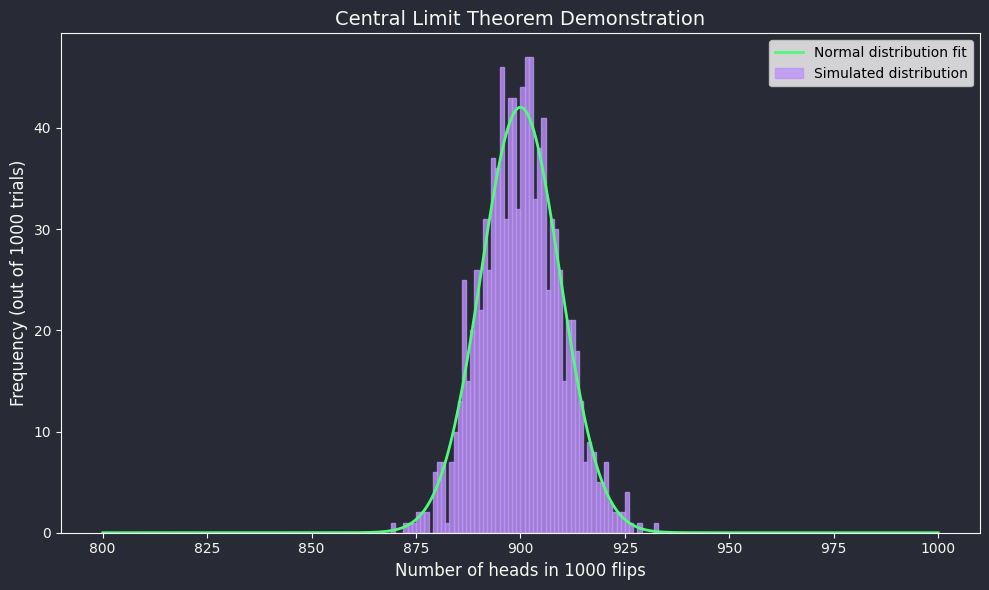

In [5]:
plot_clt(1000)

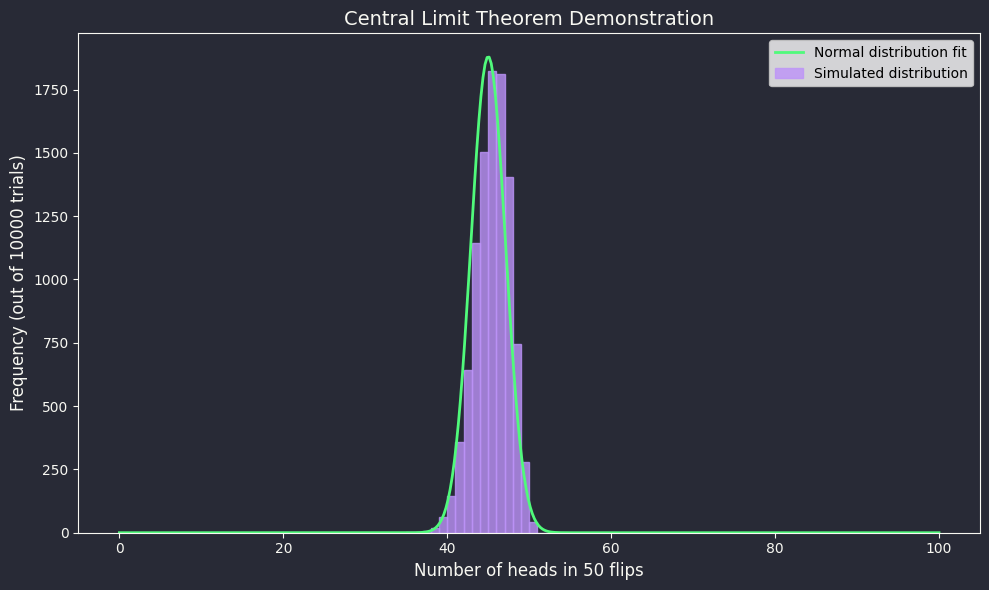

In [6]:
plot_clt(10000, 50, (0, 100))

In [7]:
def merge_images(image_paths, save_path):
    """
    Merge images into a single file.
    """

    import cv2
    import numpy as np

    images = [cv2.imread(path) for path in image_paths]

    target_size = (images[0].shape[1], images[0].shape[0])  # (width, height)
    for i in range(1, len(images)):
        images[i] = cv2.resize(images[i], target_size)

    stacked_image = np.vstack(images)
    cv2.imwrite(save_path, stacked_image)

# merge_images([
#     'Central Limit Theorem Evolution - Means of Weighted Coin Flips - 1.png',
#     'Central Limit Theorem Evolution - Means of Weighted Coin Flips - 2.png',
#     'Central Limit Theorem Evolution - Means of Weighted Coin Flips - 3.png',
# ], 'Central Limit Theorem Evolution - Means of Weighted Coin Flips.png')

# merge_images([
#     'Central Limit Theorem Evolution - Means of Weighted Coin Flips - Low N - 1.png',
#     'Central Limit Theorem Evolution - Means of Weighted Coin Flips - Low N - 2.png',
# ], 'Central Limit Theorem Evolution - Means of Weighted Coin Flips - Low N.png')



<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ll/6ymmghv964ddzxgzk0g867_w0000gn/T/ipykernel_27266/922067131.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"Gaussian Distribution with $\mu={mu}$ and $\sigma={sigma}$", color=fg_color, fontsize=14)
/var/folders/ll/6ymmghv964ddzxgzk0g867_w0000gn/T/ipykernel_27266/922067131.py:19: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Gaussian Distribution with $\mu={mu}$ and $\sigma={sigma}$", color=fg_color, fontsize=14)


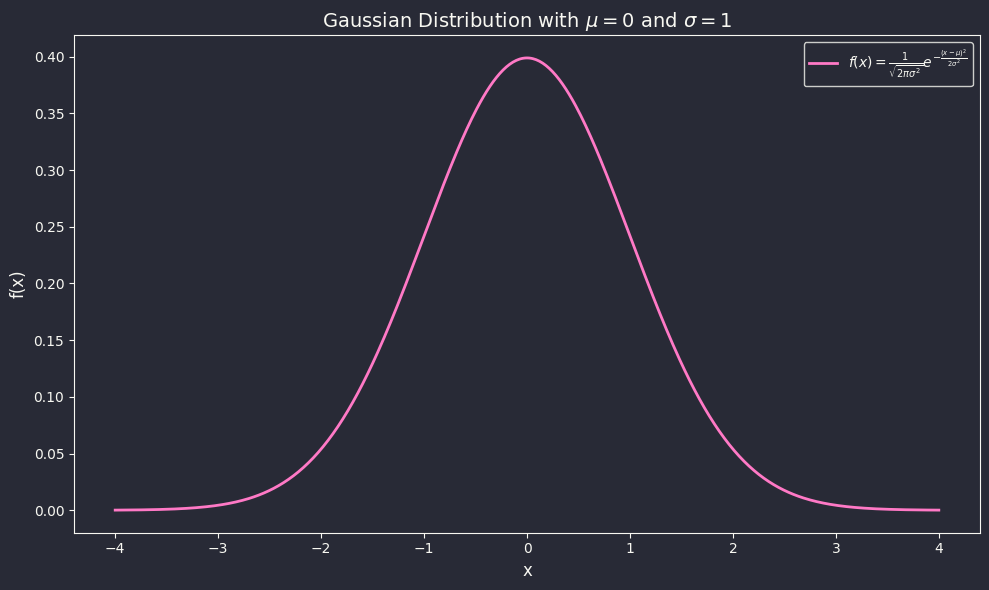

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, bernoulli, poisson, chi2

def plot_gaussian(mu=0, sigma=1):
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
    y = (1 / (np.sqrt(2 * np.pi * sigma ** 2))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

    bg_color   = '#282a36'
    fg_color   = '#f8f8f2'
    curve_color = '#ff79c6'

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    ax.plot(x, y, color=curve_color, linewidth=2)

    ax.set_title(f"Gaussian Distribution with $\mu={mu}$ and $\sigma={sigma}$", color=fg_color, fontsize=14)
    ax.set_xlabel("x", color=fg_color, fontsize=12)
    ax.set_ylabel("f(x)", color=fg_color, fontsize=12)
    ax.legend([r"$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$"], loc='upper right', facecolor=bg_color, edgecolor=fg_color, labelcolor=fg_color)

    ax.tick_params(colors=fg_color)
    for spine in ax.spines.values():
        spine.set_color(fg_color)

    plt.tight_layout()
    plt.show()

plot_gaussian()

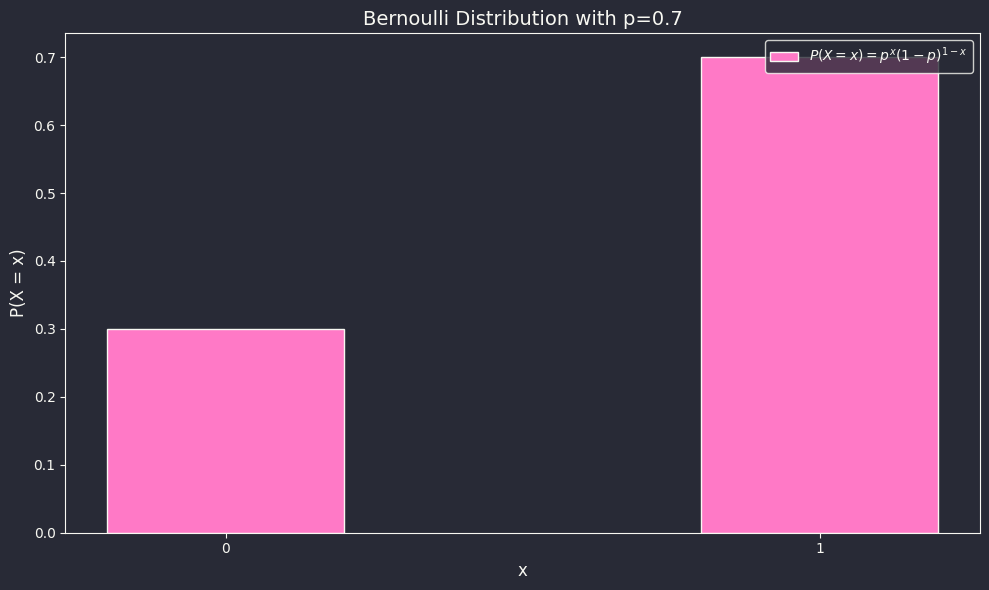

In [9]:
def plot_bernoulli(p=0.7):
    x = [0, 1]
    y = [ (1-p), p ]

    bg_color   = '#282a36'
    fg_color   = '#f8f8f2'
    bar_color  = '#ff79c6'

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    ax.bar(x, y, width=0.4, color=bar_color, edgecolor=fg_color)

    ax.set_xticks(x)
    ax.set_xticklabels(['0', '1'])
    ax.set_title(f"Bernoulli Distribution with p={p}", color=fg_color, fontsize=14)
    ax.set_xlabel("x", color=fg_color, fontsize=12)
    ax.set_ylabel("P(X = x)", color=fg_color, fontsize=12)
    ax.legend([r"$P(X = x) = p^x(1-p)^{1-x}$"], loc='upper right', facecolor=bg_color, edgecolor=fg_color, labelcolor=fg_color)

    ax.tick_params(colors=fg_color)
    for spine in ax.spines.values():
        spine.set_color(fg_color)

    plt.tight_layout()
    plt.show()

plot_bernoulli()

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/var/folders/ll/6ymmghv964ddzxgzk0g867_w0000gn/T/ipykernel_27266/1899563893.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f"Poisson Distribution with $\lambda={lam}$", color=fg_color, fontsize=14)


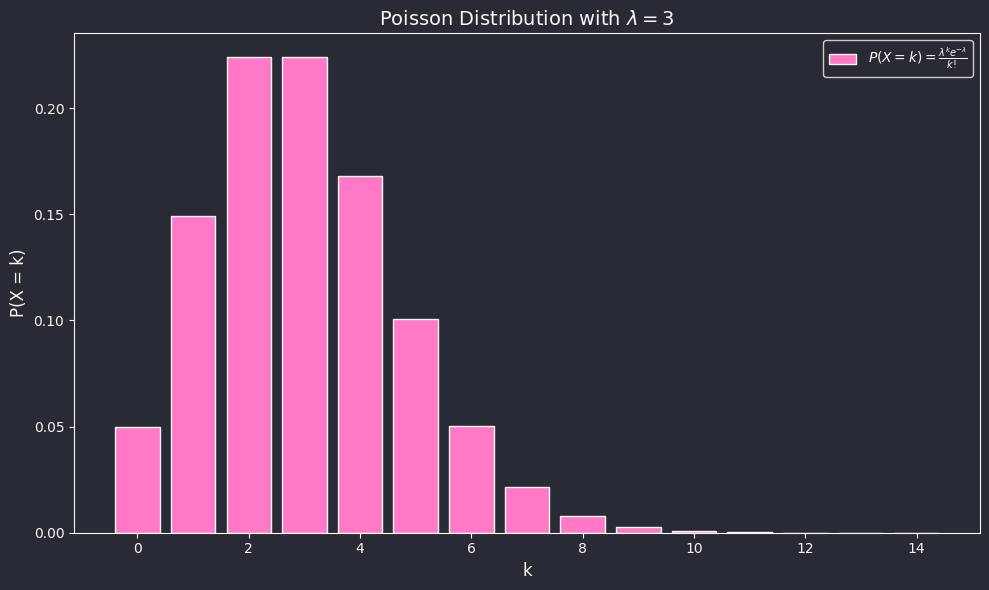

In [10]:
def plot_poisson(lam=3):
    x = np.arange(0, 15)
    y = poisson.pmf(x, mu=lam)

    bg_color   = '#282a36'
    fg_color   = '#f8f8f2'
    bar_color  = '#ff79c6'

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    ax.bar(x, y, width=0.8, color=bar_color, edgecolor=fg_color)

    ax.set_title(f"Poisson Distribution with $\lambda={lam}$", color=fg_color, fontsize=14)
    ax.set_xlabel("k", color=fg_color, fontsize=12)
    ax.set_ylabel("P(X = k)", color=fg_color, fontsize=12)
    ax.legend([r"$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$"], loc='upper right', facecolor=bg_color, edgecolor=fg_color, labelcolor=fg_color)

    ax.tick_params(colors=fg_color)
    for spine in ax.spines.values():
        spine.set_color(fg_color)

    plt.tight_layout()
    plt.show()

plot_poisson()

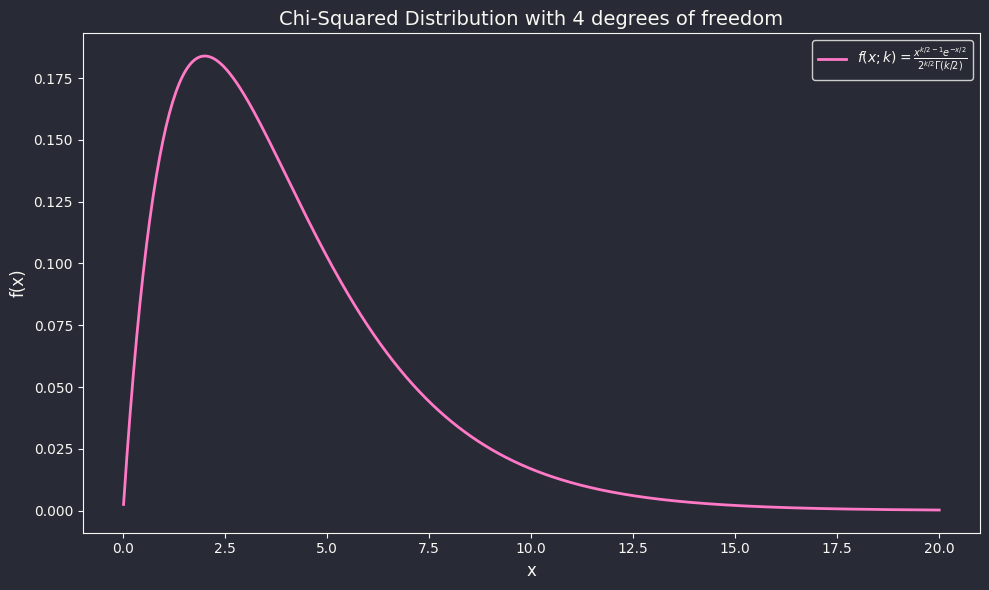

In [11]:
def plot_chi_squared(df=4):
    x = np.linspace(0.01, 20, 500)
    y = chi2.pdf(x, df)

    bg_color   = '#282a36'
    fg_color   = '#f8f8f2'
    curve_color = '#ff79c6'

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    ax.plot(x, y, color=curve_color, linewidth=2)

    ax.set_title(f"Chi-Squared Distribution with {df} degrees of freedom", color=fg_color, fontsize=14)
    ax.set_xlabel("x", color=fg_color, fontsize=12)
    ax.set_ylabel("f(x)", color=fg_color, fontsize=12)
    ax.legend([r"$f(x; k) = \frac{x^{k/2-1}e^{-x/2}}{2^{k/2}\Gamma(k/2)}$"], loc='upper right', facecolor=bg_color, edgecolor=fg_color, labelcolor=fg_color)

    ax.tick_params(colors=fg_color)
    for spine in ax.spines.values():
        spine.set_color(fg_color)

    plt.tight_layout()
    plt.show()

plot_chi_squared()

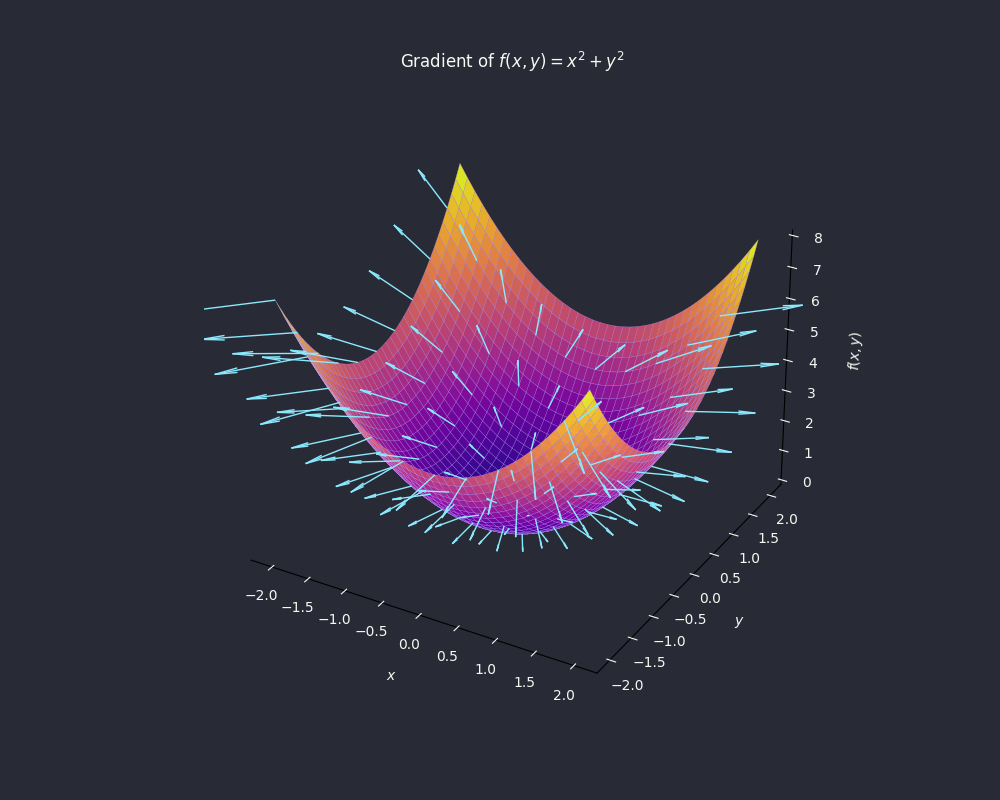

In [19]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dracula palette
bg_color = "#282a36"
fg_color = "#f8f8f2"
cyan = "#8be9fd"
purple = "#bd93f9"

# Function and gradient
def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return 2*x, 2*y

# Grid
x = np.linspace(-2, 2, 40)
y = np.linspace(-2, 2, 40)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Sparse points for arrows
step = 4
Xs = X[::step, ::step]
Ys = Y[::step, ::step]
Zs = f(Xs, Ys)
U_raw, V_raw = grad_f(Xs, Ys)
W_raw = np.zeros_like(U_raw)

# Compute magnitudes
mag = np.sqrt(U_raw**2 + V_raw**2)
max_mag = mag.max()

# Scale vectors so that the longest arrow is ~1.2 units long
scale = 1.2 / max_mag
U = U_raw * scale
V = V_raw * scale
W = W_raw * scale  # still zero

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dark theme
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Transparent panes (Matplotlib ≥3.8)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    if hasattr(axis, "set_pane_color"):
        axis.set_pane_color((0, 0, 0, 0))

# Surface
ax.plot_surface(
    X, Y, Z,
    rstride=1, cstride=1,
    cmap=plt.cm.plasma,
    edgecolor=purple,
    linewidth=0.2,
    antialiased=True,
    alpha=0.9
)

# Gradient vectors (magnitude now represented by arrow length)
ax.quiver(
    Xs, Ys, Zs,
    U, V, W,
    normalize=False,
    color=cyan,
    linewidth=1,
    arrow_length_ratio=0.25
)

# Labels, ticks, title
ax.set_xlabel('$x$', color=fg_color, labelpad=10)
ax.set_ylabel('$y$', color=fg_color, labelpad=10)
ax.set_zlabel('$f(x,y)$', color=fg_color, labelpad=10)
ax.tick_params(colors=fg_color)
ax.set_title("Gradient of $f(x, y) = x^2 + y^2$", color=fg_color, pad=20)
ax.grid(False)

plt.show()




In [20]:
# merge_images([
#     "3D Gradient Visualization - Direction and Magnitude on a Paraboloid Surface Plot - 1.png",
#     "3D Gradient Visualization - Direction and Magnitude on a Paraboloid Surface Plot - 2.png",
# ], "3D Gradient Visualization - Direction and Magnitude on a Paraboloid Surface Plot.png")

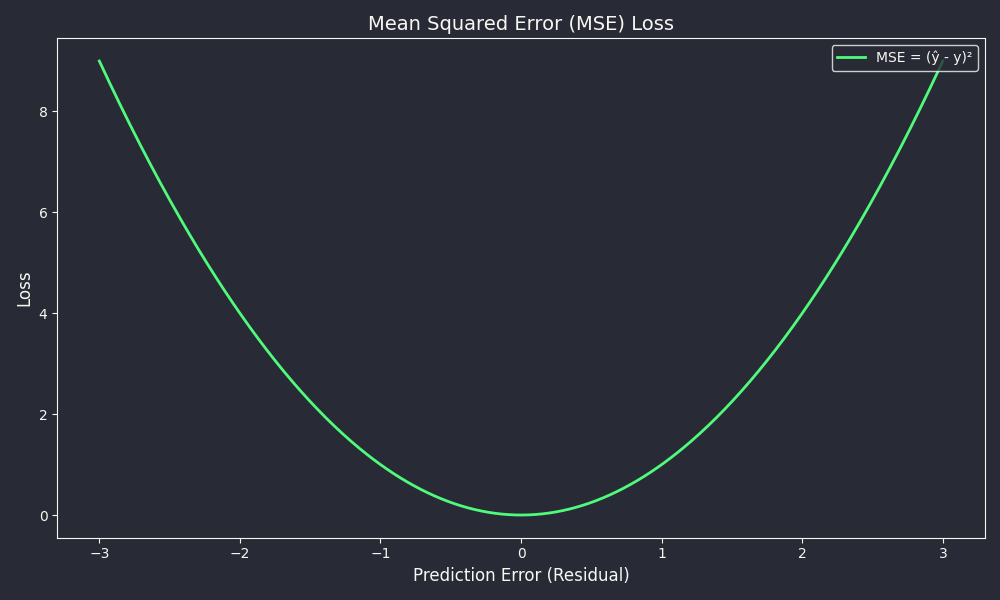

In [21]:
def plot_mse_loss():
    # Residual range
    residuals = np.linspace(-3, 3, 500)
    mse_values = residuals ** 2

    bg_color   = '#282a36'
    fg_color   = '#f8f8f2'
    curve_color = '#50fa7b'

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    ax.plot(residuals, mse_values, color=curve_color, linewidth=2)

    ax.set_title("Mean Squared Error (MSE) Loss", color=fg_color, fontsize=14)
    ax.set_xlabel("Prediction Error (Residual)", color=fg_color, fontsize=12)
    ax.set_ylabel("Loss", color=fg_color, fontsize=12)
    ax.legend(["MSE = (ŷ - y)²"], loc='upper right', facecolor=bg_color, edgecolor=fg_color, labelcolor=fg_color)

    ax.tick_params(colors=fg_color)
    for spine in ax.spines.values():
        spine.set_color(fg_color)

    plt.tight_layout()
    plt.show()

plot_mse_loss()


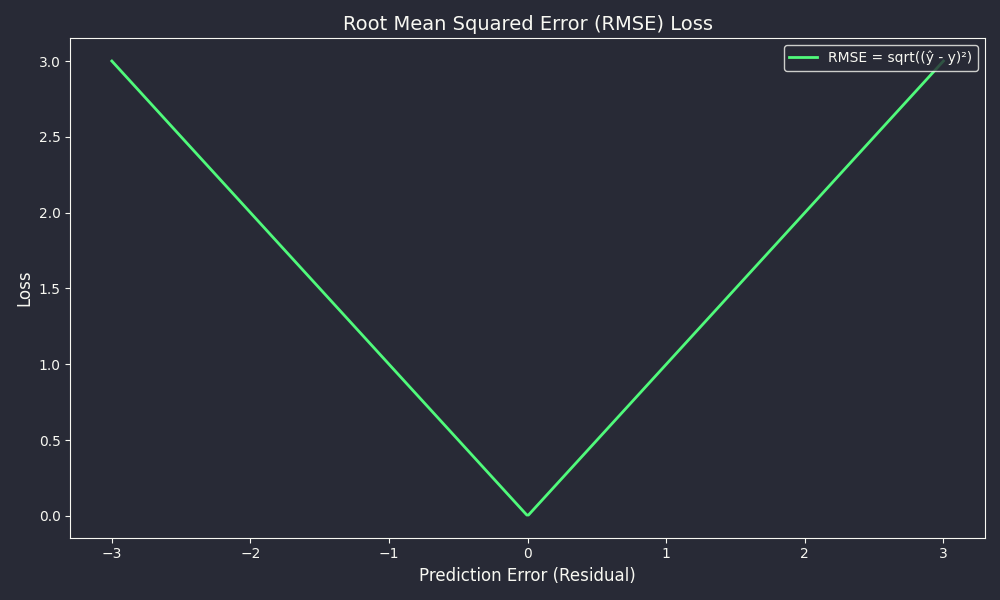

In [22]:
def plot_rmse_loss():
    # Residual range
    residuals = np.linspace(-3, 3, 500)
    rmse_values = np.sqrt(residuals ** 2)  # Equivalent to np.abs(residuals)

    bg_color   = '#282a36'
    fg_color   = '#f8f8f2'
    curve_color = '#50fa7b'

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    ax.plot(residuals, rmse_values, color=curve_color, linewidth=2)

    ax.set_title("Root Mean Squared Error (RMSE) Loss", color=fg_color, fontsize=14)
    ax.set_xlabel("Prediction Error (Residual)", color=fg_color, fontsize=12)
    ax.set_ylabel("Loss", color=fg_color, fontsize=12)
    ax.legend(["RMSE = sqrt((ŷ - y)²)"], loc='upper right', facecolor=bg_color, edgecolor=fg_color, labelcolor=fg_color)

    ax.tick_params(colors=fg_color)
    for spine in ax.spines.values():
        spine.set_color(fg_color)

    plt.tight_layout()
    plt.show()

plot_rmse_loss()

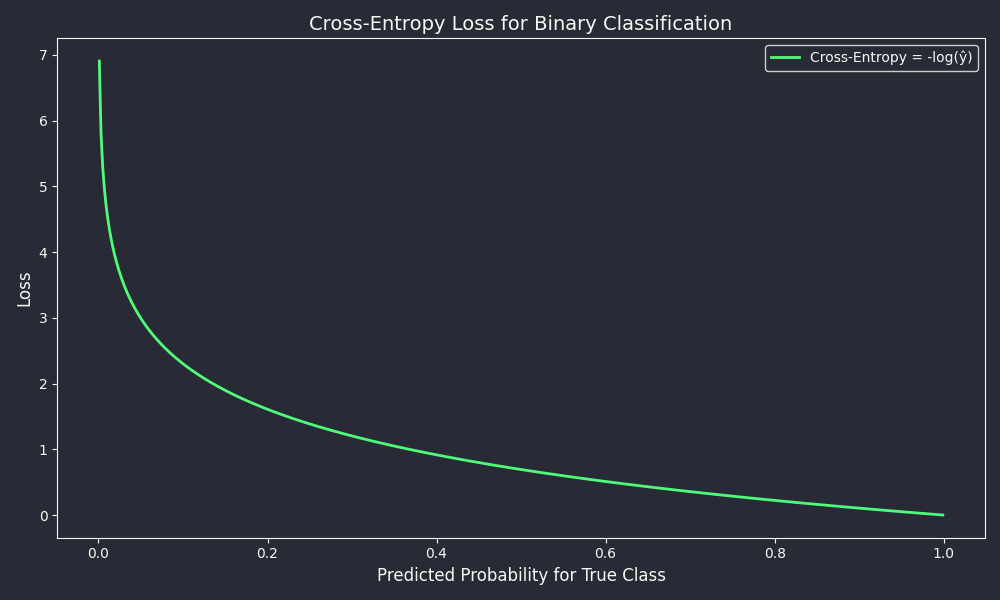

In [23]:
def plot_cross_entropy_loss():
    # Predicted probabilities between 0 and 1
    probs = np.linspace(0.001, 0.999, 500)
    ce_loss = -np.log(probs)

    bg_color   = '#282a36'
    fg_color   = '#f8f8f2'
    curve_color = '#50fa7b'

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    ax.plot(probs, ce_loss, color=curve_color, linewidth=2)

    ax.set_title("Cross-Entropy Loss for Binary Classification", color=fg_color, fontsize=14)
    ax.set_xlabel("Predicted Probability for True Class", color=fg_color, fontsize=12)
    ax.set_ylabel("Loss", color=fg_color, fontsize=12)
    ax.legend(["Cross-Entropy = -log(ŷ)"], loc='upper right', facecolor=bg_color, edgecolor=fg_color, labelcolor=fg_color)

    ax.tick_params(colors=fg_color)
    for spine in ax.spines.values():
        spine.set_color(fg_color)

    plt.tight_layout()
    plt.show()

plot_cross_entropy_loss()